# Notebook 05 — Model Evaluation

---

## Objective

This notebook performs **detailed evaluation** of the best model selected in Notebook 04.

Instead of training again, we:
1. **Load** the saved `best_model.pkl`
2. **Predict** on the test set
3. Generate detailed evaluation reports:
   - Classification Report
   - Confusion Matrix
   - ROC Curve
   - Precision-Recall Curve
4. Perform **Error Analysis** on misclassified samples

In [8]:
# ==========================================================
# Part 1 — Import Libraries
# ==========================================================

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
DATA_PATH = "/content/"
MODEL_PATH = "/content/"

# Load test data
X_test = joblib.load(DATA_PATH + "X_test.pkl")
y_test = joblib.load(DATA_PATH + "y_test.pkl")

# Load best model
best_model = joblib.load(MODEL_PATH + "best_model.pkl")

print("Best Model Loaded:")
print(f"  Type       : {type(best_model).__name__}")
print(f"  X_test     : {X_test.shape}")
print(f"  y_test     : {y_test.shape}")

Best Model Loaded:
  Type       : VotingClassifier
  X_test     : (3576, 5209)
  y_test     : (3576,)


In [10]:
# ==========================================================
# Part 3 — Predict on Test Set
# ==========================================================

y_pred = best_model.predict(X_test)

# Get probability scores if available
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:, 1]
    HAS_PROBA = True
elif hasattr(best_model, "decision_function"):
    y_prob = best_model.decision_function(X_test)
    HAS_PROBA = True
else:
    y_prob = y_pred.astype(float)
    HAS_PROBA = False

print("Predictions generated!")
print(f"  Predicted Real  (0): {(y_pred == 0).sum()}")
print(f"  Predicted Fake  (1): {(y_pred == 1).sum()}")

Predictions generated!
  Predicted Real  (0): 3427
  Predicted Fake  (1): 149


---
## Part 4 — Classification Report

In [11]:
# ==========================================================
# Part 4 — Classification Report
# ==========================================================

print("=" * 60)
print("Classification Report")
print("=" * 60)

report_text = classification_report(y_test, y_pred, target_names=["Real", "Fake"])
print(report_text)

# Also as a DataFrame for clean display
report_dict = classification_report(y_test, y_pred, target_names=["Real", "Fake"], output_dict=True)
report_df = pd.DataFrame(report_dict).T
display(report_df.style.format("{:.4f}").set_caption("Classification Report"))

# Summary metrics
print("\nSummary Metrics:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")
if HAS_PROBA:
    print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")

Classification Report
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      3403
        Fake       0.94      0.81      0.87       173

    accuracy                           0.99      3576
   macro avg       0.96      0.90      0.93      3576
weighted avg       0.99      0.99      0.99      3576



,precision,recall,f1-score,support
Real,0.9904,0.9974,0.9939,3403.0000
Fake,0.9396,0.8092,0.8696,173.0000
accuracy,0.9883,0.9883,0.9883,0.9883
macro avg,0.9650,0.9033,0.9317,3576.0000
weighted avg,0.9879,0.9883,0.9878,3576.0000



Summary Metrics:
  Accuracy  : 0.9883
  Precision : 0.9396
  Recall    : 0.8092
  F1-Score  : 0.8696


---
## Part 5 — Confusion Matrix

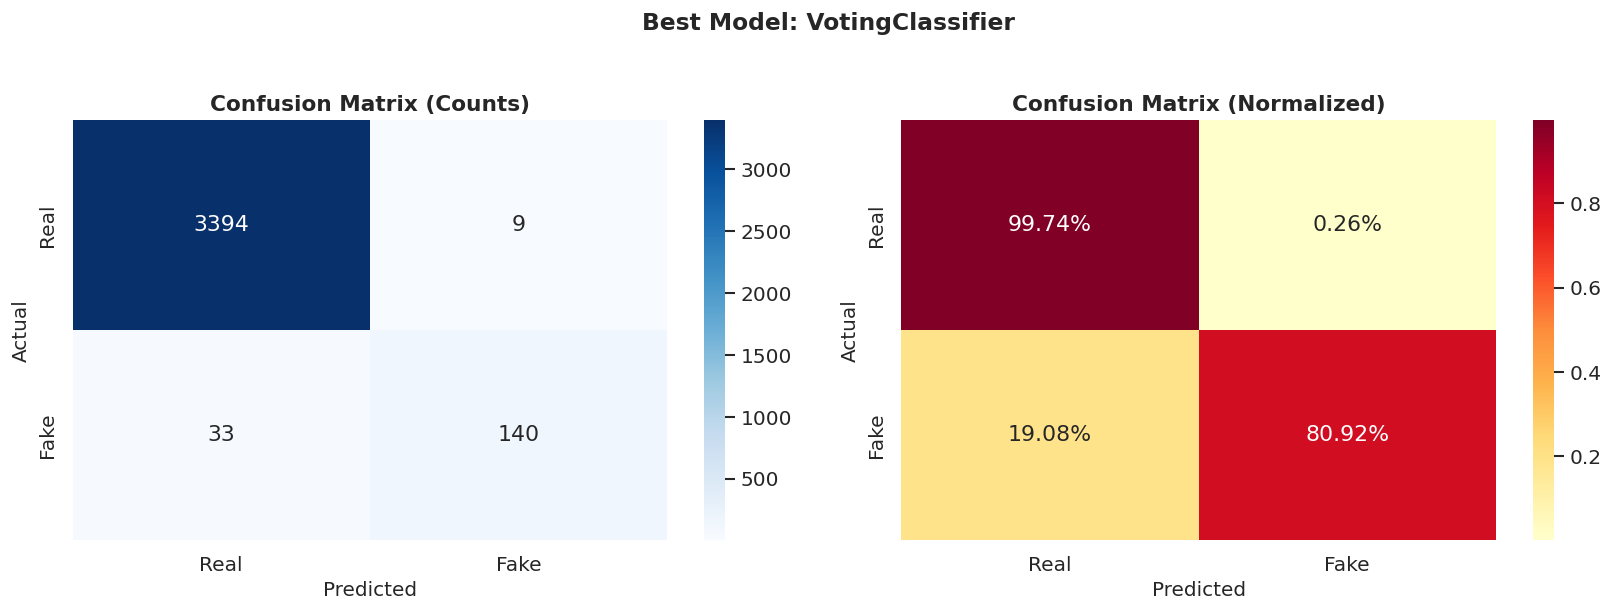


True Negatives  (Real → Real) : 3394
False Positives (Real → Fake) : 9
False Negatives (Fake → Real) : 33
True Positives  (Fake → Fake) : 140

False Positive Rate : 0.0026
False Negative Rate : 0.1908


In [14]:
import os

# ==========================================================
# Part 5 — Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"], ax=axes[0])
axes[0].set_xlabel("Predicted", fontsize=12)
axes[0].set_ylabel("Actual", fontsize=12)
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight="bold")

# Normalized (percentages)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="YlOrRd",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"], ax=axes[1])
axes[1].set_xlabel("Predicted", fontsize=12)
axes[1].set_ylabel("Actual", fontsize=12)
axes[1].set_title("Confusion Matrix (Normalized)", fontsize=13, fontweight="bold")

plt.suptitle(f"Best Model: {type(best_model).__name__}",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

# Define the directory for saving figures and create it if it doesn't exist
FIGURE_SAVE_DIR = "/content/results/figures/"
os.makedirs(FIGURE_SAVE_DIR, exist_ok=True)

plt.savefig(FIGURE_SAVE_DIR + "evaluation_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Detailed breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Real → Real) : {tn}")
print(f"False Positives (Real → Fake) : {fp}")
print(f"False Negatives (Fake → Real) : {fn}")
print(f"True Positives  (Fake → Fake) : {tp}")
print(f"\nFalse Positive Rate : {fp / (fp + tn):.4f}")
print(f"False Negative Rate : {fn / (fn + tp):.4f}")

---
## Part 6 — ROC Curve

In [15]:
# ==========================================================
# Part 6 — ROC Curve
# ==========================================================

if HAS_PROBA:
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, color="#2196F3", linewidth=2.5,
            label=f"ROC Curve (AUC = {auc_score:.4f})")
    ax.fill_between(fpr, tpr, alpha=0.15, color="#2196F3")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Random Baseline (AUC = 0.5)")

    # Mark optimal threshold (Youden's J)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    ax.scatter(fpr[optimal_idx], tpr[optimal_idx],
               color="red", s=100, zorder=5,
               label=f"Optimal Threshold = {optimal_threshold:.4f}")

    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title("ROC Curve — Best Model", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    plt.savefig("../results/figures/evaluation_roc_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: results/figures/evaluation_roc_curve.png")
else:
    print("Model does not support probability estimates — ROC curve skipped.")

Model does not support probability estimates — ROC curve skipped.


---
## Part 7 — Precision-Recall Curve

In [16]:
# ==========================================================
# Part 7 — Precision-Recall Curve
# ==========================================================

if HAS_PROBA:
    prec_vals, rec_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)
    avg_prec = average_precision_score(y_test, y_prob)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(rec_vals, prec_vals, color="#E91E63", linewidth=2.5,
            label=f"PR Curve (AP = {avg_prec:.4f})")
    ax.fill_between(rec_vals, prec_vals, alpha=0.15, color="#E91E63")

    # Baseline: proportion of positives
    baseline = (y_test == 1).sum() / len(y_test)
    ax.axhline(y=baseline, color='gray', linestyle='--', alpha=0.7,
               label=f"Baseline = {baseline:.4f}")

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve — Best Model", fontsize=14, fontweight="bold")
    ax.legend(loc="upper right", fontsize=10)
    ax.set_xlim([0, 1.05])
    ax.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.savefig("../results/figures/evaluation_pr_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: results/figures/evaluation_pr_curve.png")
else:
    print("Model does not support probability estimates — PR curve skipped.")

Model does not support probability estimates — PR curve skipped.


---
## Part 8 — Error Analysis

Analyse the **misclassified samples** to understand where the model fails.

In [17]:
# ==========================================================
# Part 8 — Error Analysis: Misclassified Samples
# ==========================================================

y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)

misclassified_mask = y_test_arr != y_pred_arr
n_misclassified = misclassified_mask.sum()

print("=" * 60)
print("Error Analysis")
print("=" * 60)

print(f"\nTotal test samples     : {len(y_test)}")
print(f"Correctly classified   : {len(y_test) - n_misclassified}")
print(f"Misclassified          : {n_misclassified}")
print(f"Error rate             : {n_misclassified / len(y_test) * 100:.2f}%")

# Break down error types
false_positives = ((y_test_arr == 0) & (y_pred_arr == 1)).sum()
false_negatives = ((y_test_arr == 1) & (y_pred_arr == 0)).sum()

print(f"\nFalse Positives (Real predicted as Fake) : {false_positives}")
print(f"False Negatives (Fake predicted as Real)  : {false_negatives}")

if false_positives + false_negatives > 0:
    print(f"\nFP / total errors : {false_positives / n_misclassified * 100:.1f}%")
    print(f"FN / total errors : {false_negatives / n_misclassified * 100:.1f}%")

Error Analysis

Total test samples     : 3576
Correctly classified   : 3534
Misclassified          : 42
Error rate             : 1.17%

False Positives (Real predicted as Fake) : 9
False Negatives (Fake predicted as Real)  : 33

FP / total errors : 21.4%
FN / total errors : 78.6%


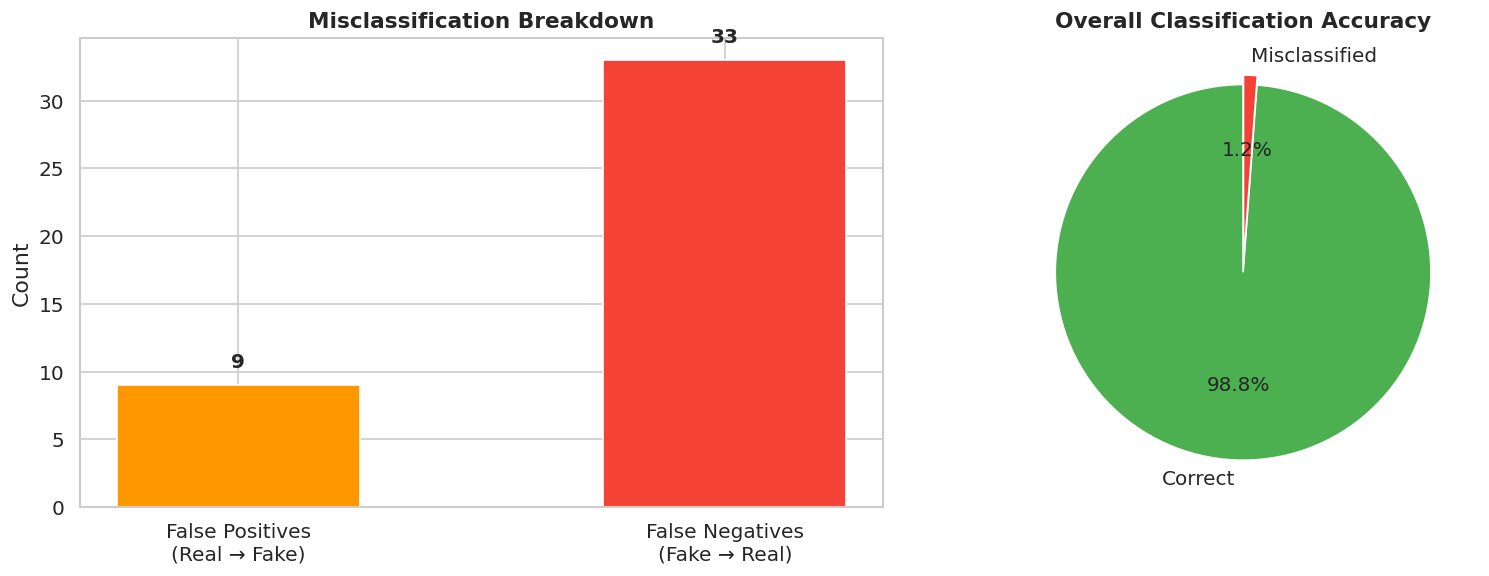

Saved: results/figures/evaluation_error_analysis.png


In [19]:
# ==========================================================
# Error Analysis — Visualization
# ==========================================================

# Error type distribution
error_data = pd.DataFrame({
    "Error Type": ["False Positives\n(Real → Fake)", "False Negatives\n(Fake → Real)"],
    "Count": [false_positives, false_negatives]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(error_data["Error Type"], error_data["Count"],
                    color=["#FF9800", "#F44336"], edgecolor="white", width=0.5)
for bar, val in zip(bars, error_data["Count"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[0].set_title("Misclassification Breakdown", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")

# Pie chart — correct vs incorrect
correct = len(y_test) - n_misclassified
axes[1].pie([correct, n_misclassified],
            labels=["Correct", "Misclassified"],
            colors=["#4CAF50", "#F44336"],
            autopct="%1.1f%%",
            startangle=90,
            textprops={"fontsize": 12},
            explode=[0, 0.05])
axes[1].set_title("Overall Classification Accuracy", fontsize=13, fontweight="bold")

plt.tight_layout()

# Ensure the FIGURE_SAVE_DIR is created
os.makedirs(FIGURE_SAVE_DIR, exist_ok=True)

plt.savefig(FIGURE_SAVE_DIR + "evaluation_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/evaluation_error_analysis.png")

In [20]:
# ==========================================================
# Error Analysis — Confidence Distribution
# ==========================================================

if HAS_PROBA:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confidence of correctly classified samples
    correct_mask = ~misclassified_mask
    axes[0].hist(y_prob[correct_mask], bins=50, color="#4CAF50",
                 alpha=0.7, edgecolor="white")
    axes[0].set_title("Confidence — Correctly Classified",
                      fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Predicted Probability (Fake)")
    axes[0].set_ylabel("Count")

    # Confidence of misclassified samples
    axes[1].hist(y_prob[misclassified_mask], bins=50, color="#F44336",
                 alpha=0.7, edgecolor="white")
    axes[1].set_title("Confidence — Misclassified",
                      fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Predicted Probability (Fake)")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    print(f"\nMean confidence (correct)      : {np.mean(np.abs(y_prob[correct_mask] - 0.5)):.4f}")
    print(f"Mean confidence (misclassified) : {np.mean(np.abs(y_prob[misclassified_mask] - 0.5)):.4f}")
else:
    print("Confidence analysis skipped — model has no probability output.")

Confidence analysis skipped — model has no probability output.


In [25]:
import os

# ==========================================================
# Error Analysis — Misclassified Sample Indices
# ==========================================================

misclassified_indices = np.where(misclassified_mask)[0]

misclassified_df = pd.DataFrame({
    "Test Index": misclassified_indices,
    "Actual": y_test_arr[misclassified_indices],
    "Predicted": y_pred_arr[misclassified_indices],
    "Error Type": np.where(
        y_test_arr[misclassified_indices] == 0,
        "False Positive",
        "False Negative"
    )
})

if HAS_PROBA:
    misclassified_df["Confidence"] = y_prob[misclassified_indices].round(4)
    misclassified_df = misclassified_df.sort_values(by="Confidence", ascending=False)

print("=" * 60)
print(f"Misclassified Samples (showing first 20 of {len(misclassified_df)})")
print("=" * 60)
display(misclassified_df.head(20).reset_index(drop=True))

# Define the directory for saving results and create it if it doesn't exist
RESULTS_SAVE_DIR = "/content/results/"
os.makedirs(RESULTS_SAVE_DIR, exist_ok=True)

# Save full misclassified samples
misclassified_df.to_csv(RESULTS_SAVE_DIR + "misclassified_samples.csv", index=False)
print(f"\nSaved: results/misclassified_samples.csv ({len(misclassified_df)} samples)")

Misclassified Samples (showing first 20 of 42)


,Test Index,Actual,Predicted,Error Type
0,332,0,1,False Positive
1,337,0,1,False Positive
2,558,1,0,False Negative
3,668,1,0,False Negative
4,754,1,0,False Negative
5,838,1,0,False Negative
6,1187,1,0,False Negative
7,1309,1,0,False Negative
8,1350,1,0,False Negative
9,1381,1,0,False Negative



Saved: results/misclassified_samples.csv (42 samples)


---
## Part 9 — Threshold Analysis (Optional)

In [26]:
# ==========================================================
# Part 9 — Threshold Analysis
# ==========================================================

if HAS_PROBA and hasattr(best_model, 'predict_proba'):
    thresholds_to_test = np.arange(0.1, 0.95, 0.05)
    threshold_results = []

    for thresh in thresholds_to_test:
        y_pred_thresh = (y_prob >= thresh).astype(int)
        threshold_results.append({
            "Threshold": round(thresh, 2),
            "Accuracy": round(accuracy_score(y_test, y_pred_thresh), 4),
            "Precision": round(precision_score(y_test, y_pred_thresh, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_thresh, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_thresh, zero_division=0), 4)
        })

    thresh_df = pd.DataFrame(threshold_results)

    print("=" * 60)
    print("Threshold Analysis")
    print("=" * 60)
    display(thresh_df)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(thresh_df["Threshold"], thresh_df["Precision"],
            marker="o", label="Precision", color="#2196F3", linewidth=2)
    ax.plot(thresh_df["Threshold"], thresh_df["Recall"],
            marker="s", label="Recall", color="#F44336", linewidth=2)
    ax.plot(thresh_df["Threshold"], thresh_df["F1-Score"],
            marker="D", label="F1-Score", color="#4CAF50", linewidth=2)

    # Mark optimal threshold
    best_thresh_idx = thresh_df["F1-Score"].idxmax()
    best_thresh = thresh_df.loc[best_thresh_idx, "Threshold"]
    ax.axvline(x=best_thresh, color="gray", linestyle="--", alpha=0.7,
               label=f"Best Threshold = {best_thresh}")

    ax.set_xlabel("Threshold", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Precision / Recall / F1 vs. Threshold",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.savefig("../results/figures/evaluation_threshold_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/figures/evaluation_threshold_analysis.png")
else:
    print("Threshold analysis skipped — model has no predict_proba.")

Threshold analysis skipped — model has no predict_proba.


---
## Part 10 — Evaluation Summary

In [27]:
# ==========================================================
# Part 10 — Evaluation Summary
# ==========================================================

print("=" * 60)
print("NOTEBOOK 05 — MODEL EVALUATION SUMMARY")
print("=" * 60)

print(f"\n  Model Type            : {type(best_model).__name__}")
print(f"  Test Samples          : {len(y_test)}")
print(f"  Accuracy              : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision             : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall                : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score              : {f1_score(y_test, y_pred):.4f}")
if HAS_PROBA:
    print(f"  ROC-AUC               : {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n  Total Misclassified   : {n_misclassified}")
print(f"  False Positives       : {false_positives}")
print(f"  False Negatives       : {false_negatives}")

print("\n  Figures Saved:")
figures_saved = [
    "evaluation_confusion_matrix.png",
    "evaluation_roc_curve.png",
    "evaluation_pr_curve.png",
    "evaluation_error_analysis.png",
    "evaluation_threshold_analysis.png"
]
for f in figures_saved:
    print(f"    - results/figures/{f}")

print(f"\n  CSV Saved:")
print(f"    - results/misclassified_samples.csv")

print("\n" + "=" * 60)
print("✅ Notebook 05 completed. Model evaluation is complete.")
print("=" * 60)

NOTEBOOK 05 — MODEL EVALUATION SUMMARY

  Model Type            : VotingClassifier
  Test Samples          : 3576
  Accuracy              : 0.9883
  Precision             : 0.9396
  Recall                : 0.8092
  F1-Score              : 0.8696

  Total Misclassified   : 42
  False Positives       : 9
  False Negatives       : 33

  Figures Saved:
    - results/figures/evaluation_confusion_matrix.png
    - results/figures/evaluation_roc_curve.png
    - results/figures/evaluation_pr_curve.png
    - results/figures/evaluation_error_analysis.png
    - results/figures/evaluation_threshold_analysis.png

  CSV Saved:
    - results/misclassified_samples.csv

✅ Notebook 05 completed. Model evaluation is complete.
